# Install and import packages

In [3]:
# !pip install opencv-python

In [4]:
# !pip install tensorflow

In [42]:
import cv2  # used to read images
import numpy as np
import os
import matplotlib.pyplot as plt

# Decide path and files

In [43]:
# Here we define the path for images of infected and not infected cells
path = '/scratch/grp/msc_appbio/AI/Assessment/AD/'

In [44]:
NoImpairment = os.path.join(path, 'NoImpairment/')
MildImpairment = os.path.join(path, 'MildImpairment/')
ModerateImpairment = os.path.join(path, 'ModerateImpairment/')

print("Number of NoImpairment", len(os.listdir(NoImpairment)))
print("Number of MildImpairment", len(os.listdir(MildImpairment)))
print("Number of ModerateImpairment", len(os.listdir(ModerateImpairment)))

Number of NoImpairment 2560
Number of MildImpairment 1792
Number of ModerateImpairment 724


# Load images

In [45]:
def load_images(directories, n_images=6000):
    """
    Reads in images and assigns class labels
    Parameters:
        directories: A list of the sub-directories
        n_images:    The maximum number of images to load from each directory
    Returns:
        images (numpy.ndarray) : Image data
        label (numpy.ndarray      : Labels of each image
    """
    images = []
    labels = []
    for label, sub_dir in enumerate(directories):
        num=1
        for file_name in os.listdir(sub_dir):
            if num > n_images:
                break
            img_path = os.path.join(sub_dir, file_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (224, 224))  # Resize to a consistent shape
                # cv2 reads the images backwards ie BGR. Here we convert to RGB
                # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # convert to grayscale  - COMMENT OUT IF YOU WANT TO USE COLOUR IMAGES
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                images.append(img)
                labels.append(label)  # 0 for Uninfected 1 for Parasitized
                num+=1
    return np.array(images), np.array(labels)

In [46]:
images, labels = load_images([NoImpairment, MildImpairment, ModerateImpairment])

In [47]:
images.shape 

(5076, 224, 224)

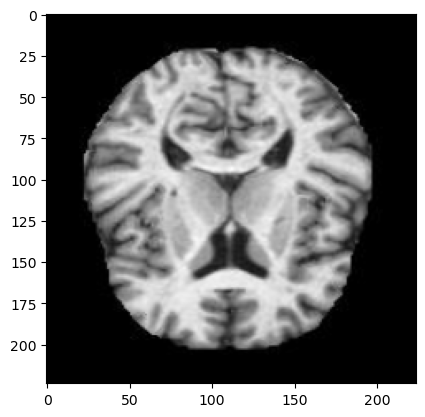

In [48]:
plt.imshow(images[100], cmap='gray')

# Change the data range from 1-256 to 0-1

In [49]:
np.max(images[600])

np.uint8(254)

In [50]:
# The image data range from 0 to 255.
# We need to perform pixel normalisation to change the data to the range 0 to 1
images=images/255

In [51]:
np.max(images[600])

np.float64(0.996078431372549)

# Design training and testing set

In [52]:
# Let us split the data into a training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=6821)

In [53]:
y_train[190:250]

array([1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0])

In [54]:
X_train.shape


(4060, 224, 224)

In [33]:
X_test.shape

(1016, 224, 224)

# One-hot encoding

In [55]:
import tensorflow
# do one-hot-encoding
y_train_ohe = tensorflow.keras.utils.to_categorical(y_train, num_classes=3)
# also for the test set
y_test_ohe= tensorflow.keras.utils.to_categorical(y_test, num_classes=3)

In [56]:
y_test_ohe[190:195]

array([[0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

# Data augmentation

In [57]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(0.01),
    tf.keras.layers.RandomContrast(0.01),
    # tf.keras.layers.RandomRotation(0.1),
    # tf.keras.layers.RandomZoom(0.1),
    # tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# Define CNN model

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.regularizers import l2
import gc

In [62]:
# re-train model
tensorflow.keras.backend.clear_session()
gc.collect()


0

In [63]:

model = Sequential( [
 Input(shape=(224,224,1)),
    # data_augmentation,
 # Conv2D(32, (3, 3), activation='relu'), # Use 30 filters with a 3x3 kernel
 # MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3,3), activation='relu'),
    # BatchNormalization(),
    # Dropout(0.1),
    MaxPooling2D(pool_size=(2, 2)),
 # Conv2D(64, (3, 3), activation='relu'), # Increase number of filters
 # MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3,3), activation='relu'),
    # BatchNormalization(),
    # Dropout(0.15),
    MaxPooling2D(pool_size=(2, 2)),

 # Conv2D(128, (3, 3), activation='relu'), # Increase number of filters
 # MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3,3), activation='relu'),
    # BatchNormalization(),
    # Dropout(0.2),
    MaxPooling2D(pool_size=(2, 2)),

    # GlobalAveragePooling2D(),
    # Dense(128, activation="relu"),
    # Dropout(0.4),
    Flatten(),
 Dense(512, activation='relu'),  # Put into a dense layer size
    
 Dense(3, activation='softmax')  
] )

# Define various aspects of the running(compile) of the model

In [64]:
from tensorflow.keras.optimizers import Adam

# Here we use the binary(two class) cross entropy rather than categorical cross entropy since there are only two classes.
model.compile(optimizer=Adam(learning_rate= 0.0001),
                loss='categorical_crossentropy',
                #loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])

In [65]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,397,059 (169.36 MB)

 Trainable params: 44,397,059 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
import numpy as np
# from sklearn.utils.class_weight import compute_class_weight

#classes = np.unique(y_train)

#weights = compute_class_weight(
    #class_weight="balanced",
    #classes=classes,
    #y=y_train
#)

#class_weight = dict(zip(classes, weights))

#print("Class weights:", class_weight)

history = model.fit(
    X_train,
    y_train_ohe,          # for one-hot
    batch_size=100,
    epochs=40,
    validation_split=0.2,
    class_weight=class_weight
)

Class weights: {np.int64(0): np.float64(0.6534685337196201), np.int64(1): np.float64(0.950374531835206), np.int64(2): np.float64(2.3952802359882006)}
Epoch 1/40
 4/33 ━━━━━━━━━━━━━━━━━━━━ 25s 876ms/step - accuracy: 0.2419 - loss: 1.2633

KeyboardInterrupt: 

# Fit/Train the model

In [21]:
history = model.fit(x=X_train, y=y_train_ohe, batch_size=100,
                      epochs=30, shuffle=True,
                      validation_split=0.2)

Epoch 1/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 714ms/step - accuracy: 0.5092 - loss: 0.9966 - val_accuracy: 0.5394 - val_loss: 0.8897
Epoch 2/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 711ms/step - accuracy: 0.5631 - loss: 0.8947 - val_accuracy: 0.5493 - val_loss: 0.8950
Epoch 3/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 715ms/step - accuracy: 0.5924 - loss: 0.8462 - val_accuracy: 0.6502 - val_loss: 0.7677
Epoch 4/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 720ms/step - accuracy: 0.6438 - loss: 0.7675 - val_accuracy: 0.6466 - val_loss: 0.7344
Epoch 5/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 722ms/step - accuracy: 0.6866 - loss: 0.6971 - val_accuracy: 0.7081 - val_loss: 0.6737
Epoch 6/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 718ms/step - accuracy: 0.7325 - loss: 0.6383 - val_accuracy: 0.7451 - val_loss: 0.6222
Epoch 7/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 714ms/step - accuracy: 0.7789 - loss: 0.5547 - val_accuracy: 0.7574 - val_loss: 0.5653
Epoch 8/45
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 717ms/step - accuracy: 0.8217 - loss: 0.4893 - val_accu

In [40]:
# history2 = model.fit(
    X_train,
    y_train_ohe,
    batch_size=50,
    epochs=80,
    initial_epoch=60,
    shuffle=True,
    validation_split=0.25
)

Epoch 61/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6842 - loss: 0.6415 - val_accuracy: 0.7415 - val_loss: 0.6489
Epoch 62/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6698 - loss: 0.6613 - val_accuracy: 0.7477 - val_loss: 0.6412
Epoch 63/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6821 - loss: 0.6367 - val_accuracy: 0.7385 - val_loss: 0.6498
Epoch 64/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6615 - loss: 0.6603 - val_accuracy: 0.7231 - val_loss: 0.6943
Epoch 65/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6883 - loss: 0.6275 - val_accuracy: 0.7723 - val_loss: 0.6139
Epoch 66/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6749 - loss: 0.6301 - val_accuracy: 0.7600 - val_loss: 0.6757
Epoch 67/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6903 - loss: 0.6321 - val_accuracy: 0.7354 - val_loss: 0.6347
Epoch 68/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6986 - loss: 0.5890 - val_accuracy: 0.7692 - v

In [46]:
epochs = history.epoch

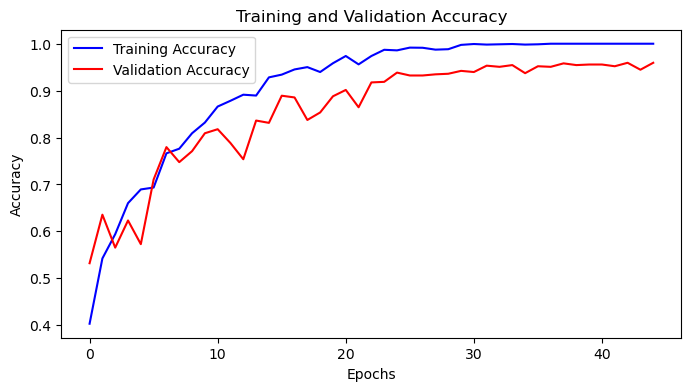

In [47]:
accuracy_values = history.history['accuracy']
val_accuracy_values = history.history['val_accuracy']

# If the validation accuracy or loss differ significantly from the training, this is evidence of overfitting
plt.figure(figsize=(8, 4))
plt.plot(epochs, accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy_values, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

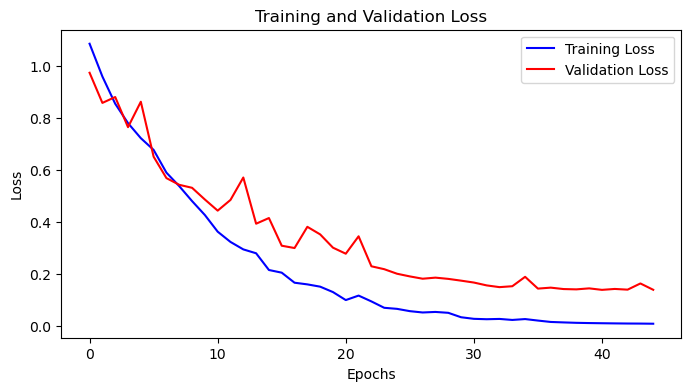

In [48]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_values, 'b', label='Training Loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [49]:
# Use the model to make predictions on the testset
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


In [50]:
# These are the actual predictions ( ie the class with the max value)
y_pred[1:10]

array([0, 1, 0, 2, 1, 1, 0, 0, 0])

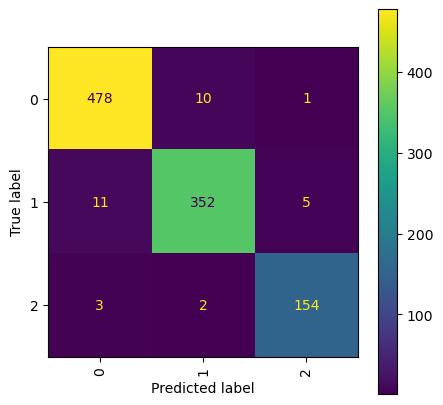

In [51]:
# Plot the CM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm  = confusion_matrix(y_test, y_pred)
cmdisp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(5, 5))
cmdisp.plot(include_values=True, cmap="viridis", ax=ax, xticks_rotation="vertical")
plt.show()


In [52]:
from sklearn.metrics  import classification_report
print('Classification Report:')
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       489
           1       0.97      0.96      0.96       368
           2       0.96      0.97      0.97       159

    accuracy                           0.97      1016
   macro avg       0.97      0.97      0.97      1016
weighted avg       0.97      0.97      0.97      1016



# Another model with data weight



# Use Transfer learning

In [1]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

if len(X_train.shape) == 3:
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# 關鍵：使用 ResNetV2 專用的預處理（將像素縮放到 -1 ~ 1）
X_train_rgb = preprocess_input(X_train_rgb)
X_test_rgb = preprocess_input(X_test_rgb)

print(X_train_rgb.shape) # 輸出應為 (樣本數, 224, 224, 3)

2026-01-25 14:47:15.249465: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 14:47:17.184106: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-25 14:47:25.579271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


NameError: name 'X_train' is not defined

In [ ]:
resnet_model = ResNet50V2(
    weights='imagenet',
    include_top=False,  # this removes the final classification layer of the model so we can add to it.
    input_shape= (224,224,3)
)

In [ ]:
# We are going to add extra trainable layers to the ResNet NN so we can train on our data
# We can unfreeze all of the ResNet convolutional layers, keeping the weights from their pre-training against millions of images
resnet_model.trainable = True
# However, re-training all the layers will be slow.
# So here, only the last 5 layers are set to be re-trained against our dataset
for layer in resnet_model.layers[:-5]:
    layer.trainable = False

In [ ]:
resnet_model.layers

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Resizing, Lambda, Input
from tensorflow.keras.models import Sequential
preprocessing_model = Sequential([
    # define the shape of the image ( and number of colours)
    Input(shape=(224,224,3)),
    # For gray-scale this would be,
    # Input(shape=(224,224,1)),
    #
    # If we are not using a tensorflow "layer", we have to call it as a function using Lambda
    # This could be a user defined function
    #Lambda(lambda image: tf.image.grayscale_to_rgb(image)),
    #
    # We can add image augmentation steps here
    #
    #tensorflow.keras.layers.Rescaling(1./255),  # This is not needed here since we have already done this previously
    #Since some of the images are odd shapes, we can zoom out so if we rotate, parts of the image don't disappear
    tensorflow.keras.layers.RandomZoom(height_factor=(0.3,0.3), width_factor=(0.3,0.3),fill_mode="constant"),
    tensorflow.keras.layers.RandomRotation(factor=(-0.1,0.1), fill_mode="constant",interpolation='bilinear'), # % of 2*PI radians rotation
    tensorflow.keras.layers.RandomFlip("horizontal_and_vertical"),
    # get rid of empty space around the borders after rotation
    Lambda( lambda image: tf.image.resize_with_crop_or_pad(image,target_height=224,target_width=224)),
    #tensorflow.keras.layers.RandomContrast(factor=(-0.2,0.2)),
    # if after adjusting the contrast or brightness, some pixel values might go above 1 so we need to reset them
    Lambda( lambda image: tf.clip_by_value(image,0,1)),
    # if we do not have any augmentation or a Lambda function(grayscale), we need to perform some function (ie Resizing) just so there is actually something to do in this pipeline
    Resizing(224, 224)
])

In [ ]:
import random
random_image = random.randint(0, 600)
augmented_image = preprocessing_model(tf.expand_dims(X_train[random_image], axis=0))
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(X_train[random_image])
axs[1].imshow(augmented_image[0])


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

# 清除 Keras 內部狀態
K.clear_session()
# 強制回收記憶體
gc.collect()

In [ ]:
from tensorflow.keras.layers import Input, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Rescaling

# Now create our final model by combining the preprocessing step, Resnet and adding custom layers
model = Sequential( [
 preprocessing_model,
 resnet_model,
 GlobalAveragePooling2D(), # Global Average Pooling layer
 # we could add more Conv2d layers here
 #Dense(512, activation='relu'),
 Dense(128, activation='relu'),
 #Dropout(0.5), # Dropout for regularization to stop overfitting
 Dense(3, activation='sigmoid')  # Gives either class 0 or 1
] )

In [ ]:
from tensorflow.keras.optimizers import Adam

# Here we use the binary(two class) cross entropy rather than categorical cross entropy since there are only two classes.
model.compile(optimizer=Adam(learning_rate= 0.00001),
                loss='categorical_crossentropy',
                #loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])

In [ ]:
# Note how many parameters there are to train and how big your dataset it
model.summary()

In [ ]:
history = model.fit(x=X_train_rgb, y=y_train_ohe, batch_size=200,
                      epochs=50, shuffle=True,
                      validation_split=0.2)

In [ ]:
print(y_train_ohe.shape)